# Inferential Statistics – Practical

We'll work through confidence intervals, hypothesis tests, and interpret p-values using `scipy.stats` and `statsmodels`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Confidence Intervals

We'll estimate the mean height of a population from a sample.

In [2]:
# Simulated height data (population: mean=170, std=10)
population = np.random.normal(loc=170, scale=10, size=10_000)
sample = np.random.choice(population, size=50)  # take a sample of 50

n    = len(sample)
xbar = sample.mean()
s    = sample.std(ddof=1)  # sample std dev
se   = s / np.sqrt(n)      # standard error

# 95% CI using t-distribution (σ unknown)
ci_95 = stats.t.interval(confidence=0.95, df=n-1, loc=xbar, scale=se)
ci_99 = stats.t.interval(confidence=0.99, df=n-1, loc=xbar, scale=se)

print(f"Sample mean:         {xbar:.2f} cm")
print(f"95% Confidence Interval: ({ci_95[0]:.2f}, {ci_95[1]:.2f})")
print(f"99% Confidence Interval: ({ci_99[0]:.2f}, {ci_99[1]:.2f})")
print(f"True population mean: {population.mean():.2f} cm")

Sample mean:         170.97 cm
95% Confidence Interval: (167.76, 174.19)
99% Confidence Interval: (166.68, 175.27)
True population mean: 169.98 cm


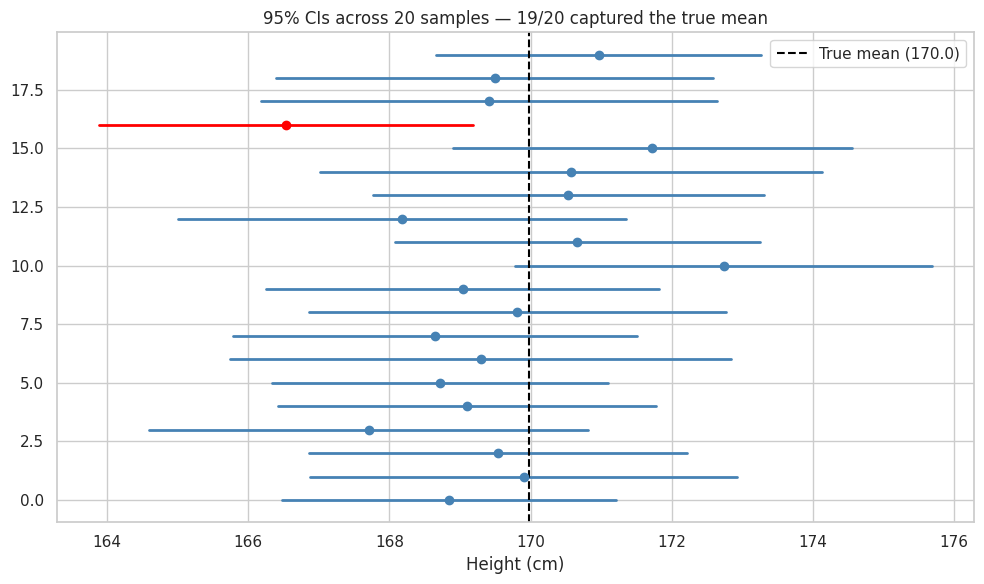

In [3]:
# Visualise: draw 20 samples and show how often the CI captures the true mean
true_mean = population.mean()
n_experiments = 20

fig, ax = plt.subplots(figsize=(10, 6))
captured = 0

for i in range(n_experiments):
    samp = np.random.choice(population, size=50)
    m = samp.mean()
    se_ = samp.std(ddof=1) / np.sqrt(50)
    lo, hi = stats.t.interval(0.95, df=49, loc=m, scale=se_)
    color = 'steelblue' if lo <= true_mean <= hi else 'red'
    if color == 'steelblue':
        captured += 1
    ax.plot([lo, hi], [i, i], color=color, linewidth=2)
    ax.scatter(m, i, color=color, zorder=5)

ax.axvline(true_mean, color='black', linestyle='--', label=f'True mean ({true_mean:.1f})')
ax.set_title(f'95% CIs across {n_experiments} samples — {captured}/{n_experiments} captured the true mean')
ax.set_xlabel('Height (cm)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. One-Sample t-Test

**Scenario:** A factory claims its widgets weigh 500g on average.  
We weigh a sample and test if the true mean equals 500g.

In [4]:
weights = np.array([498, 502, 497, 503, 499, 501, 496, 504, 498, 500,
                    495, 505, 497, 503, 499, 501, 502, 498, 500, 496])

# H0: μ = 500  (factory claim)
# H1: μ ≠ 500  (two-tailed)
t_stat, p_value = stats.ttest_1samp(weights, popmean=500)

print(f"Sample mean:  {weights.mean():.2f} g")
print(f"t-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_value:.4f}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"p < {alpha} → REJECT H₀: Mean is significantly different from 500g")
else:
    print(f"p ≥ {alpha} → FAIL TO REJECT H₀: No significant difference from 500g")

Sample mean:  499.70 g
t-statistic:  -0.4679
p-value:      0.6452

p ≥ 0.05 → FAIL TO REJECT H₀: No significant difference from 500g


### From-Scratch: Bootstrap Confidence Interval vs the Parametric t-CI

Resample the 20 widget weights *with replacement* 100,000 times, take the mean of each resample,
and read the 2.5th/97.5th percentiles off that distribution of means — no normality assumption, no
t-distribution formula. Compare directly to the parametric `xbar ± t * SE` interval.

In [5]:
rng = np.random.default_rng(42)
n_boot = 100_000
boot_means = np.empty(n_boot)
for i in range(n_boot):
    resample = rng.choice(weights, size=len(weights), replace=True)
    boot_means[i] = resample.mean()

boot_lo, boot_hi = np.percentile(boot_means, [2.5, 97.5])

n_w = len(weights)
xbar_w = weights.mean()
s_w = weights.std(ddof=1)
se_w = s_w / np.sqrt(n_w)
t_lo, t_hi = stats.t.interval(0.95, df=n_w - 1, loc=xbar_w, scale=se_w)

print(f"sample mean:                    {xbar_w:.3f} g")
print(f"bootstrap 95% CI (percentile):  ({boot_lo:.3f}, {boot_hi:.3f})")
print(f"parametric t-based 95% CI:      ({t_lo:.3f}, {t_hi:.3f})")

sample mean:                    499.700 g
bootstrap 95% CI (percentile):  (498.500, 500.950)
parametric t-based 95% CI:      (498.358, 501.042)


## 3. Independent Two-Sample t-Test

**Scenario:** Do students in Group A score higher than Group B on a test?

In [6]:
group_a = np.array([85, 88, 90, 82, 91, 87, 84, 89, 86, 92])
group_b = np.array([78, 82, 80, 76, 83, 79, 81, 77, 80, 85])

# Check variance equality first (Levene's test)
levene_stat, levene_p = stats.levene(group_a, group_b)
equal_var = levene_p > 0.05
print(f"Levene's test p-value: {levene_p:.4f} → {'equal' if equal_var else 'unequal'} variances\n")

# H0: μA = μB  |  H1: μA ≠ μB
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=equal_var)

print(f"Group A mean: {group_a.mean():.1f}")
print(f"Group B mean: {group_b.mean():.1f}")
print(f"t-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_value:.6f}")

if p_value < 0.05:
    print("\nREJECT H₀: Significant difference between groups")

# Cohen's d effect size
pooled_std = np.sqrt((group_a.var(ddof=1) + group_b.var(ddof=1)) / 2)
cohens_d = (group_a.mean() - group_b.mean()) / pooled_std
print(f"Cohen's d:    {cohens_d:.3f}  (large effect)")

Levene's test p-value: 0.5100 → equal variances

Group A mean: 87.4
Group B mean: 80.1
t-statistic:  5.4529
p-value:      0.000035

REJECT H₀: Significant difference between groups
Cohen's d:    2.439  (large effect)


### From-Scratch: Permutation Test vs the Independent t-Test

Under H0 (no real difference between groups), the group label is meaningless — shuffle it. Pool
both groups, repeatedly reassign 10 values to "A" and 10 to "B" at random, and record how often the
shuffled mean difference is at least as extreme as the one actually observed. That fraction *is*
the p-value, with no distributional assumption at all.

In [7]:
observed_diff = group_a.mean() - group_b.mean()

pooled = np.concatenate([group_a, group_b])
n_a = len(group_a)
n_perm = 100_000
count_extreme = 0
for i in range(n_perm):
    shuffled = rng.permutation(pooled)
    perm_a = shuffled[:n_a]
    perm_b = shuffled[n_a:]
    diff = perm_a.mean() - perm_b.mean()
    if abs(diff) >= abs(observed_diff):
        count_extreme += 1

perm_p_value = count_extreme / n_perm
t_stat_ab, ttest_p_value = stats.ttest_ind(group_a, group_b, equal_var=True)

print(f"observed mean difference (A - B): {observed_diff:.3f}")
print(f"permutation test p-value (two-sided, {n_perm} shuffles): {perm_p_value:.5f}")
print(f"independent t-test p-value:                        {ttest_p_value:.5f}")

observed mean difference (A - B): 7.300
permutation test p-value (two-sided, 100000 shuffles): 0.00012
independent t-test p-value:                        0.00004


## 4. Paired t-Test

**Scenario:** Blood pressure measured *before* and *after* a treatment. Patients are paired with themselves.

In [8]:
before = np.array([140, 145, 138, 150, 142, 155, 148, 143, 151, 146])
after  = np.array([130, 138, 132, 142, 136, 148, 140, 137, 143, 139])

# H0: mean difference = 0  |  H1: mean difference ≠ 0
t_stat, p_value = stats.ttest_rel(before, after)

print(f"Mean before: {before.mean():.1f} mmHg")
print(f"Mean after:  {after.mean():.1f} mmHg")
print(f"Mean reduction: {(before - after).mean():.1f} mmHg")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

if p_value < 0.05:
    print("\nREJECT H₀: Treatment significantly reduced blood pressure")

Mean before: 145.8 mmHg
Mean after:  138.5 mmHg
Mean reduction: 7.3 mmHg
t-statistic: 18.4431
p-value:     0.000000

REJECT H₀: Treatment significantly reduced blood pressure


## 5. ANOVA — Testing 3+ Groups

**Scenario:** Three fertiliser types — do they produce different crop yields?

F-statistic: 70.9678
p-value:     0.000000

REJECT H₀: At least one fertiliser produces a significantly different yield
→ Run post-hoc tests to find WHICH groups differ


/tmp/ipykernel_245917/30603409.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fertiliser', y='yield', data=data, palette='Set2')


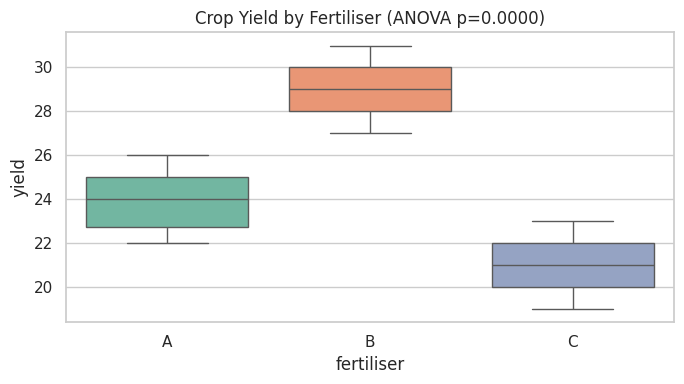

In [9]:
fertiliser_a = np.array([22, 24, 25, 23, 26, 22, 24, 25])
fertiliser_b = np.array([28, 30, 27, 29, 31, 30, 28, 29])
fertiliser_c = np.array([20, 22, 21, 19, 23, 20, 21, 22])

f_stat, p_value = stats.f_oneway(fertiliser_a, fertiliser_b, fertiliser_c)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

if p_value < 0.05:
    print("\nREJECT H₀: At least one fertiliser produces a significantly different yield")
    print("→ Run post-hoc tests to find WHICH groups differ")

# Visualise
data = pd.DataFrame({
    'yield': np.concatenate([fertiliser_a, fertiliser_b, fertiliser_c]),
    'fertiliser': ['A']*8 + ['B']*8 + ['C']*8
})
plt.figure(figsize=(7, 4))
sns.boxplot(x='fertiliser', y='yield', data=data, palette='Set2')
plt.title(f'Crop Yield by Fertiliser (ANOVA p={p_value:.4f})')
plt.tight_layout()
plt.show()

## 6. Chi-Square Test — Categorical Association

**Scenario:** Is there a relationship between gender and product preference?

In [10]:
# Contingency table: rows=gender, cols=product preference
observed = np.array([[30, 10, 20],   # Male: Product A, B, C
                     [15, 25, 10]])  # Female: Product A, B, C

chi2, p_value, dof, expected = stats.chi2_contingency(observed)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")
print("\nExpected frequencies:")
print(np.round(expected, 1))

if p_value < 0.05:
    print("\nREJECT H₀: Gender and product preference are NOT independent")
else:
    print("\nFAIL TO REJECT H₀: No significant association between gender and product preference")

Chi-square statistic: 13.9683
Degrees of freedom:   2
p-value:              0.0009

Expected frequencies:
[[24.5 19.1 16.4]
 [20.5 15.9 13.6]]

REJECT H₀: Gender and product preference are NOT independent


## 7. Normality Testing

Before running parametric tests (t-test, ANOVA), verify normality.

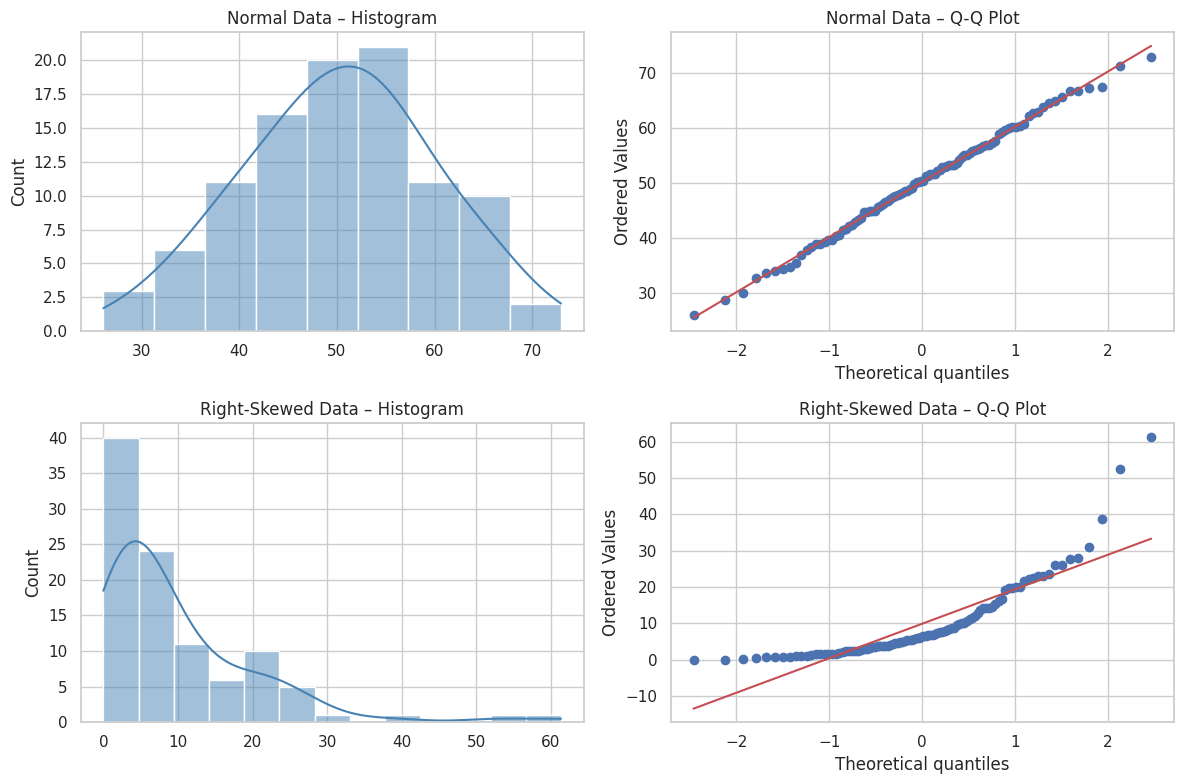

Normal: W=0.9812, p=0.6021 → Normally distributed
Skewed: W=0.7451, p=0.0000 → NOT normally distributed


In [11]:
normal_data = np.random.normal(50, 10, 100)
skewed_data = np.random.exponential(10, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (data, name) in enumerate([(normal_data, 'Normal'), (skewed_data, 'Right-Skewed')]):
    # Histogram with KDE
    sns.histplot(data, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{name} Data – Histogram')
    
    # Q-Q plot
    stats.probplot(data, plot=axes[i, 1])
    axes[i, 1].set_title(f'{name} Data – Q-Q Plot')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test (best for n < 50; here we use first 50 observations)
for data, name in [(normal_data[:50], 'Normal'), (skewed_data[:50], 'Skewed')]:
    stat, p = stats.shapiro(data)
    verdict = 'Normally distributed' if p > 0.05 else 'NOT normally distributed'
    print(f"{name}: W={stat:.4f}, p={p:.4f} → {verdict}")

## 8. p-Value Visualisation

Building intuition for what a p-value actually means.

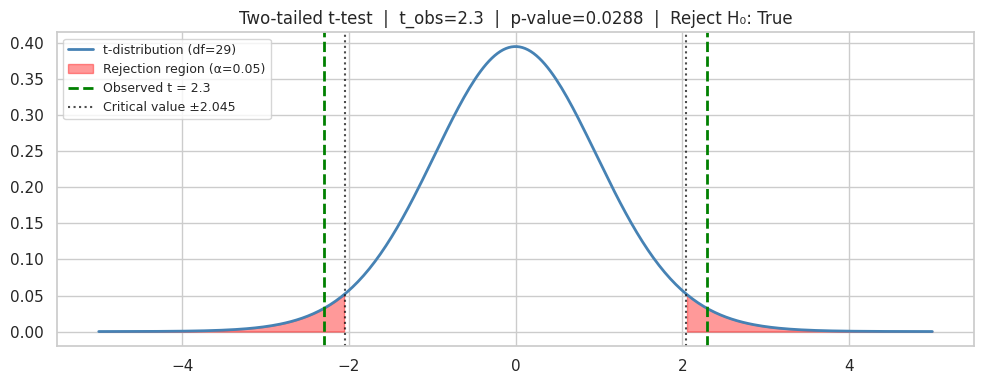

In [12]:
# Visualise two-tailed t-test rejection region
df_val = 29  # degrees of freedom (n=30)
t_critical = stats.t.ppf(0.975, df=df_val)  # α=0.05 two-tailed

x = np.linspace(-5, 5, 300)
y = stats.t.pdf(x, df=df_val)

plt.figure(figsize=(10, 4))
plt.plot(x, y, color='steelblue', linewidth=2, label='t-distribution (df=29)')

# Shade rejection regions (α/2 on each tail)
plt.fill_between(x, y, where=(x <= -t_critical), color='red', alpha=0.4, label=f'Rejection region (α=0.05)')
plt.fill_between(x, y, where=(x >= t_critical), color='red', alpha=0.4)

# Example test statistic
t_obs = 2.3
plt.axvline(t_obs, color='green', linestyle='--', linewidth=2, label=f'Observed t = {t_obs}')
plt.axvline(-t_obs, color='green', linestyle='--', linewidth=2)

plt.axvline(t_critical, color='black', linestyle=':', alpha=0.7, label=f'Critical value ±{t_critical:.3f}')
plt.axvline(-t_critical, color='black', linestyle=':', alpha=0.7)

p_val = 2 * stats.t.sf(abs(t_obs), df=df_val)
plt.title(f'Two-tailed t-test  |  t_obs={t_obs}  |  p-value={p_val:.4f}  |  Reject H₀: {p_val < 0.05}')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()